# UQ-SHRED Comprehensive Experiments: Flow Over Cylinder

Complete experimental suite:
- **E1-E6:** All experiments from experiments.md specification

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
import os
from datetime import datetime
import json

from processdata import load_data, TimeSeriesDataset
from models import SHRED, UQ_SHRED, UQ_Forecaster, fit, fit_uq
import uq

device = 'cuda' if torch.cuda.is_available() else 'cpu'
dataset_name = 'FLOW'
print(f'Using device: {device}')

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
results_dir = f'results/{dataset_name}_{timestamp}'
os.makedirs(results_dir, exist_ok=True)
print(f'Results: {results_dir}')

np.random.seed(42)
torch.manual_seed(42)

config = {'dataset': dataset_name, 'device': device, 'seed': 42, 'timestamp': timestamp}

Using device: cuda
Results: results/FLOW_20260214_172454


In [2]:
# Data
num_sensors = 100
lags = 50

load_X = load_data(dataset_name)
n, m = load_X.shape
print(f'{dataset_name} shape: {load_X.shape}')

sensor_locations = np.random.choice(m, size=num_sensors, replace=False)
config.update({'num_sensors': num_sensors, 'lags': lags, 'data_shape': load_X.shape})

(573, 400000)
FLOW shape: (573, 400000)


In [3]:
# Split
n_total = n - lags
train_size = int(0.80 * n_total)
valid_size = int(0.05 * n_total)

train_indices = np.arange(0, train_size)
valid_indices = np.arange(train_size, train_size + valid_size)
test_indices = np.arange(train_size + valid_size, n_total)

print(f'Train: {len(train_indices)}, Valid: {len(valid_indices)}, Test: {len(test_indices)}')
config['split'] = {'train': len(train_indices), 'valid': len(valid_indices), 'test': len(test_indices)}

Train: 418, Valid: 26, Test: 79


In [4]:
# Normalize
sc = MinMaxScaler()
sc = sc.fit(load_X[train_indices])
transformed_X = sc.transform(load_X)

all_data_in = np.zeros((n - lags, lags, num_sensors))
for i in range(len(all_data_in)):
    all_data_in[i] = transformed_X[i:i+lags, sensor_locations]

train_data_in = torch.tensor(all_data_in[train_indices], dtype=torch.float32).to(device)
valid_data_in = torch.tensor(all_data_in[valid_indices], dtype=torch.float32).to(device)
test_data_in = torch.tensor(all_data_in[test_indices], dtype=torch.float32).to(device)

train_data_out = torch.tensor(transformed_X[train_indices + lags - 1], dtype=torch.float32).to(device)
valid_data_out = torch.tensor(transformed_X[valid_indices + lags - 1], dtype=torch.float32).to(device)
test_data_out = torch.tensor(transformed_X[test_indices + lags - 1], dtype=torch.float32).to(device)

train_dataset = TimeSeriesDataset(train_data_in, train_data_out)
valid_dataset = TimeSeriesDataset(valid_data_in, valid_data_out)
test_dataset = TimeSeriesDataset(test_data_in, test_data_out)

print(f'Input: {train_data_in.shape}, Output: {train_data_out.shape}')

Input: torch.Size([418, 50, 100]), Output: torch.Size([418, 400000])


# E1: Reconstruction

In [5]:
# SHRED
shred = SHRED(num_sensors, m, hidden_size=64, hidden_layers=2, l1=350, l2=400, dropout=0.01).to(device)
fit(shred, train_dataset, valid_dataset, batch_size=20, num_epochs=1000, lr=1e-3, verbose=True, patience=50)

shred.eval()
with torch.no_grad():
    shred_recon = shred(test_dataset.X)
    shred_error = (torch.linalg.norm(shred_recon - test_dataset.Y) / torch.linalg.norm(test_dataset.Y)).item()
print(f'SHRED: {shred_error:.4f}')

Training epoch 1
Error tensor(0.7038, device='cuda:0')
Training epoch 20
Error tensor(0.1660, device='cuda:0')
Training epoch 40
Error tensor(0.1183, device='cuda:0')
Training epoch 60
Error tensor(0.1022, device='cuda:0')
Training epoch 80
Error tensor(0.0958, device='cuda:0')
Training epoch 100
Error tensor(0.0887, device='cuda:0')
Training epoch 120
Error tensor(0.0864, device='cuda:0')
Training epoch 140
Error tensor(0.0774, device='cuda:0')
Training epoch 160
Error tensor(0.0774, device='cuda:0')
Training epoch 180
Error tensor(0.0858, device='cuda:0')
Training epoch 200
Error tensor(0.0770, device='cuda:0')
Training epoch 220
Error tensor(0.0682, device='cuda:0')
Training epoch 240
Error tensor(0.0660, device='cuda:0')
Training epoch 260
Error tensor(0.0643, device='cuda:0')
Training epoch 280
Error tensor(0.0784, device='cuda:0')
Training epoch 300
Error tensor(0.0665, device='cuda:0')
Training epoch 320
Error tensor(0.0565, device='cuda:0')
Training epoch 340
Error tensor(0.057

In [6]:
# UQ-SHRED
uq_shred = UQ_SHRED(num_sensors, m, hidden_size=64, hidden_layers=2, l1=350, l2=400, dropout=0.1, noise_dim=500).to(device)
fit_uq(uq_shred, train_dataset, valid_dataset, batch_size=20, num_epochs=1000, lr=1e-3, verbose=True, patience=50)

uq_shred.eval()
samples = uq_shred.sample(test_dataset.X, n_samples=50)
samples_np = samples.cpu().numpy()

mean_recon = samples.mean(dim=0)
median_recon = torch.tensor(np.median(samples_np, axis=0), dtype=torch.float32).to(device)
std_recon = samples.std(dim=0)

uq_mean_error = (torch.linalg.norm(mean_recon - test_dataset.Y) / torch.linalg.norm(test_dataset.Y)).item()
uq_median_error = (torch.linalg.norm(median_recon - test_dataset.Y) / torch.linalg.norm(test_dataset.Y)).item()

print(f'UQ Mean: {uq_mean_error:.4f}, UQ Median: {uq_median_error:.4f}')

Epoch 1: error=0.7082
Epoch 20: error=0.6429
Epoch 40: error=0.4438
Epoch 60: error=0.2741
Epoch 80: error=0.1934
Epoch 100: error=0.1678
Epoch 120: error=0.1453
Epoch 140: error=0.1304
Epoch 160: error=0.1276
Epoch 180: error=0.1222
Epoch 200: error=0.1118
Epoch 220: error=0.1078
Epoch 240: error=0.1062
Epoch 260: error=0.1011
Epoch 280: error=0.1008
Epoch 300: error=0.0999
Epoch 320: error=0.0886
Epoch 340: error=0.0872
Epoch 360: error=0.0929
Epoch 380: error=0.0832
Epoch 400: error=0.0846
Epoch 420: error=0.0784
Epoch 440: error=0.0688
Epoch 460: error=0.0749
Epoch 480: error=0.0713
Epoch 500: error=0.0772
Epoch 520: error=0.0712
Epoch 540: error=0.0820
Epoch 560: error=0.0799
Epoch 580: error=0.0706
Epoch 600: error=0.0730
Epoch 620: error=0.0656
Epoch 640: error=0.0631
Epoch 660: error=0.0579
Epoch 680: error=0.0610
Epoch 700: error=0.0629
Epoch 720: error=0.0567
Epoch 740: error=0.0689
Epoch 760: error=0.0553
Epoch 780: error=0.0573
Epoch 800: error=0.0593
Epoch 820: error=0.063

In [7]:
# Metrics
crps_score = uq.crps(samples, test_dataset.Y)
sharp = uq.sharpness(samples, conf=0.95)
cal_scores = uq.calibration_scores(samples, test_dataset.Y, levels=[0.5, 0.7, 0.9, 0.95, 0.99])

errors = torch.abs(test_dataset.Y - mean_recon).flatten().cpu().numpy()
stds = std_recon.flatten().cpu().numpy()
corr = np.corrcoef(stds, errors)[0, 1]

print('\n=== E1 Metrics ===')
print(f'SHRED:      {shred_error:.4f}')
print(f'UQ Mean:    {uq_mean_error:.4f}')
print(f'UQ Median:  {uq_median_error:.4f}')
print(f'CRPS:       {crps_score:.4f}')
print(f'Sharpness:  {sharp:.4f}')
print(f'Coverage:   {cal_scores[0.95]*100:.1f}%')
print(f'Corr:       {corr:.3f}')


=== E1 Metrics ===
SHRED:      0.0349
UQ Mean:    0.0468
UQ Median:  0.0465
CRPS:       0.0095
Sharpness:  0.0361
Coverage:   64.3%
Corr:       0.394


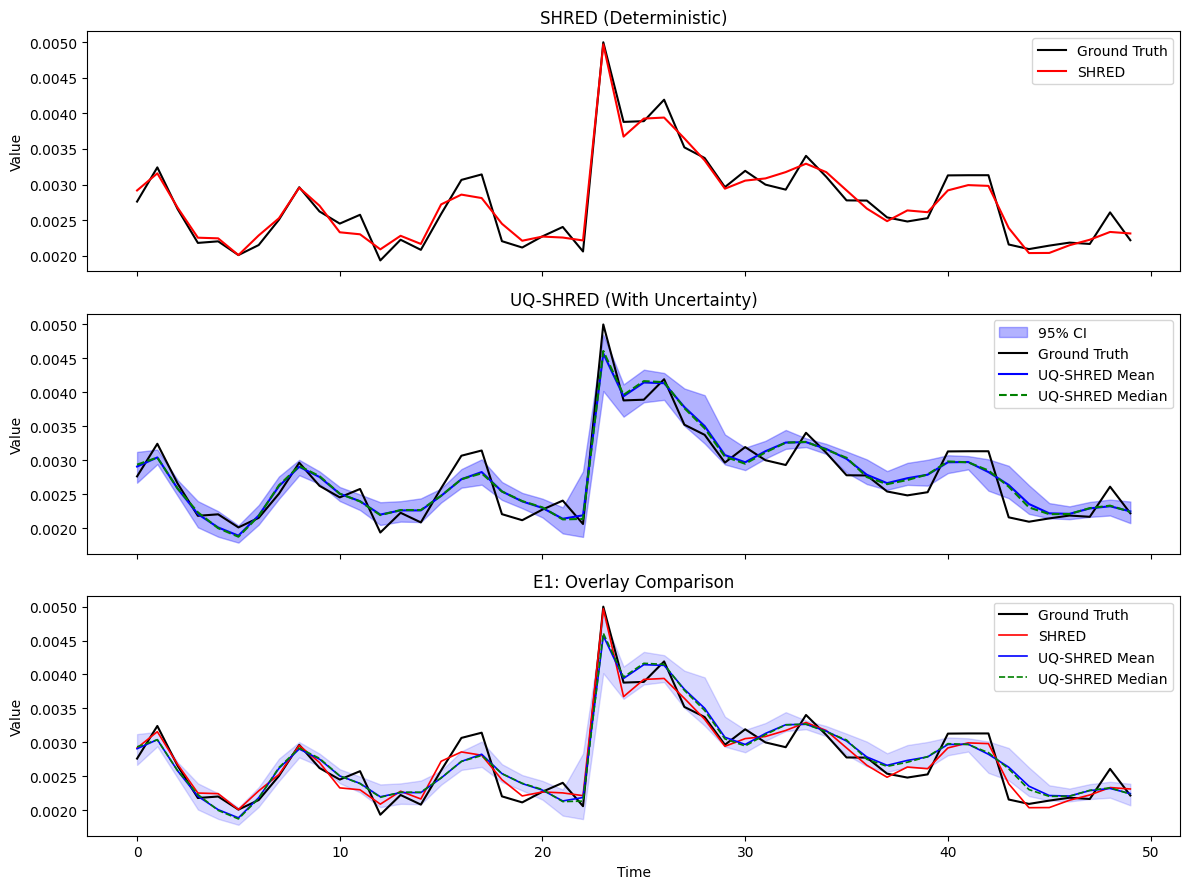

In [8]:
# E1 Visualization: Reconstruction Comparison
shred_recon_np = sc.inverse_transform(shred_recon.cpu().numpy())
test_truth_np = sc.inverse_transform(test_dataset.Y.cpu().numpy())
samples_orig = np.array([sc.inverse_transform(s) for s in samples_np])
mean_orig = samples_orig.mean(axis=0)
median_orig = np.median(samples_orig, axis=0)
lower_orig = np.percentile(samples_orig, 2.5, axis=0)
upper_orig = np.percentile(samples_orig, 97.5, axis=0)

# Three-panel comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
idx = sensor_locations[0]
t = np.arange(50)

# SHRED (deterministic)
axes[0].plot(t, test_truth_np[:50, idx], 'k-', label='Ground Truth')
axes[0].plot(t, shred_recon_np[:50, idx], 'r-', label='SHRED')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].set_title('SHRED (Deterministic)')

# UQ-SHRED (with uncertainty)
axes[1].fill_between(t, lower_orig[:50, idx], upper_orig[:50, idx], alpha=0.3, color='blue', label='95% CI')
axes[1].plot(t, test_truth_np[:50, idx], 'k-', label='Ground Truth')
axes[1].plot(t, mean_orig[:50, idx], 'b-', label='UQ-SHRED Mean')
axes[1].plot(t, median_orig[:50, idx], 'g--', label='UQ-SHRED Median')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].set_title('UQ-SHRED (With Uncertainty)')

# Overlay comparison
axes[2].plot(t, test_truth_np[:50, idx], 'k-', linewidth=1.5, label='Ground Truth')
axes[2].plot(t, shred_recon_np[:50, idx], 'r-', linewidth=1.2, label='SHRED')
axes[2].plot(t, mean_orig[:50, idx], 'b-', linewidth=1.2, label='UQ-SHRED Mean')
axes[2].plot(t, median_orig[:50, idx], 'g--', linewidth=1.2, label='UQ-SHRED Median')
axes[2].fill_between(t, lower_orig[:50, idx], upper_orig[:50, idx], alpha=0.15, color='blue')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Value')
axes[2].legend()
axes[2].set_title('E1: Overlay Comparison')

plt.tight_layout()
plt.savefig(f'{results_dir}/E1_reconstruction_comparison.png', dpi=150)
plt.show()

# E2: Calibration

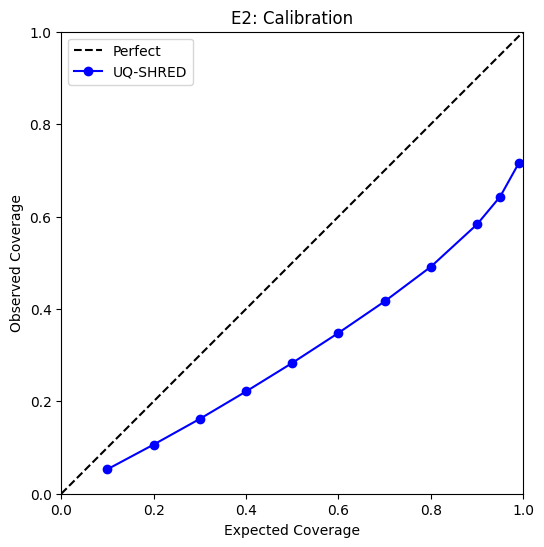

E2: Calibration
  50% → 28.3%
  70% → 41.6%
  90% → 58.3%
  95% → 64.3%
  99% → 71.5%


In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
uq.plot_calibration(samples, test_dataset.Y, ax=ax)
ax.set_title('E2: Calibration')
plt.savefig(f'{results_dir}/E2_calibration.png', dpi=150)
plt.show()

print('E2: Calibration')
for level, obs in cal_scores.items():
    print(f'  {level*100:.0f}% → {obs*100:.1f}%')

# E3: Uncertainty-Error Relationship

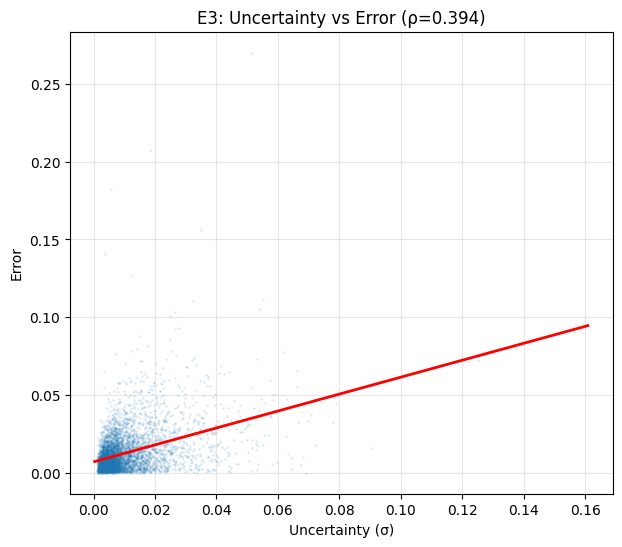

E3: ρ = 0.3939


In [10]:
idx = np.random.choice(len(errors), min(5000, len(errors)), replace=False)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(stds[idx], errors[idx], alpha=0.1, s=1)
z = np.polyfit(stds[idx], errors[idx], 1)
p = np.poly1d(z)
x_line = np.linspace(stds.min(), stds.max(), 100)
ax.plot(x_line, p(x_line), 'r-', linewidth=2)
ax.set_title(f'E3: Uncertainty vs Error (ρ={corr:.3f})')
ax.set_xlabel('Uncertainty (σ)')
ax.set_ylabel('Error')
ax.grid(alpha=0.3)
plt.savefig(f'{results_dir}/E3_uncertainty_vs_error.png', dpi=150)
plt.show()

print(f'E3: ρ = {corr:.4f}')

# E4: Spatial Uncertainty

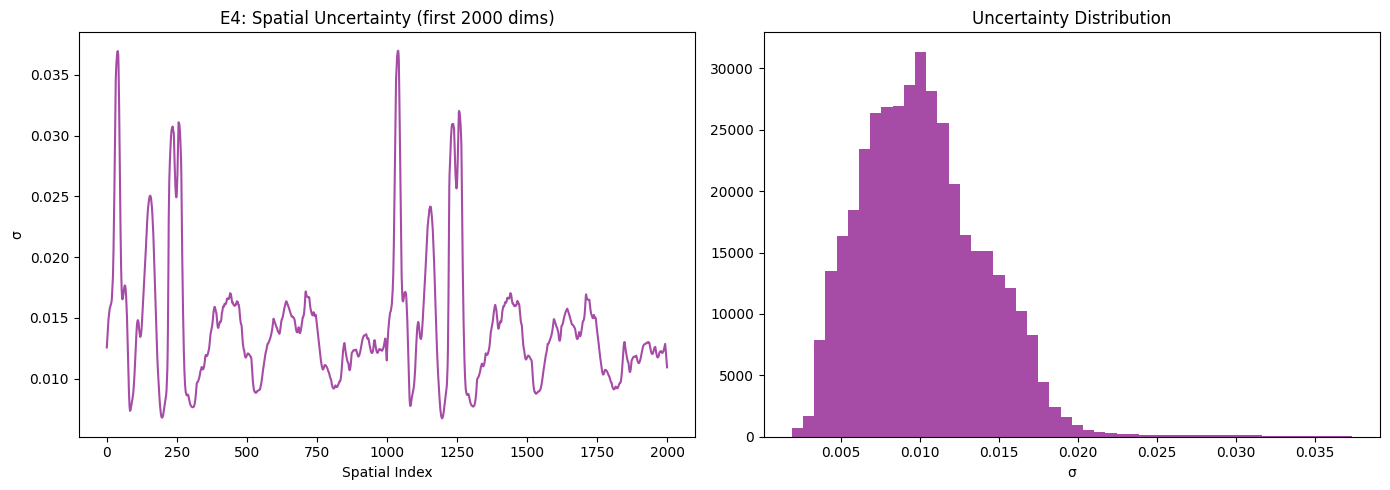

E4: Mean=0.0103, Max=0.0373, Min=0.0019


In [11]:
avg_std = std_recon.cpu().numpy().mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(avg_std[:2000], alpha=0.7, color='purple')
axes[0].set_title('E4: Spatial Uncertainty (first 2000 dims)')
axes[0].set_xlabel('Spatial Index')
axes[0].set_ylabel('σ')

axes[1].hist(avg_std, bins=50, alpha=0.7, color='purple')
axes[1].set_title('Uncertainty Distribution')
axes[1].set_xlabel('σ')

plt.tight_layout()
plt.savefig(f'{results_dir}/E4_spatial_uncertainty.png', dpi=150)
plt.show()

print(f'E4: Mean={avg_std.mean():.4f}, Max={avg_std.max():.4f}, Min={avg_std.min():.4f}')

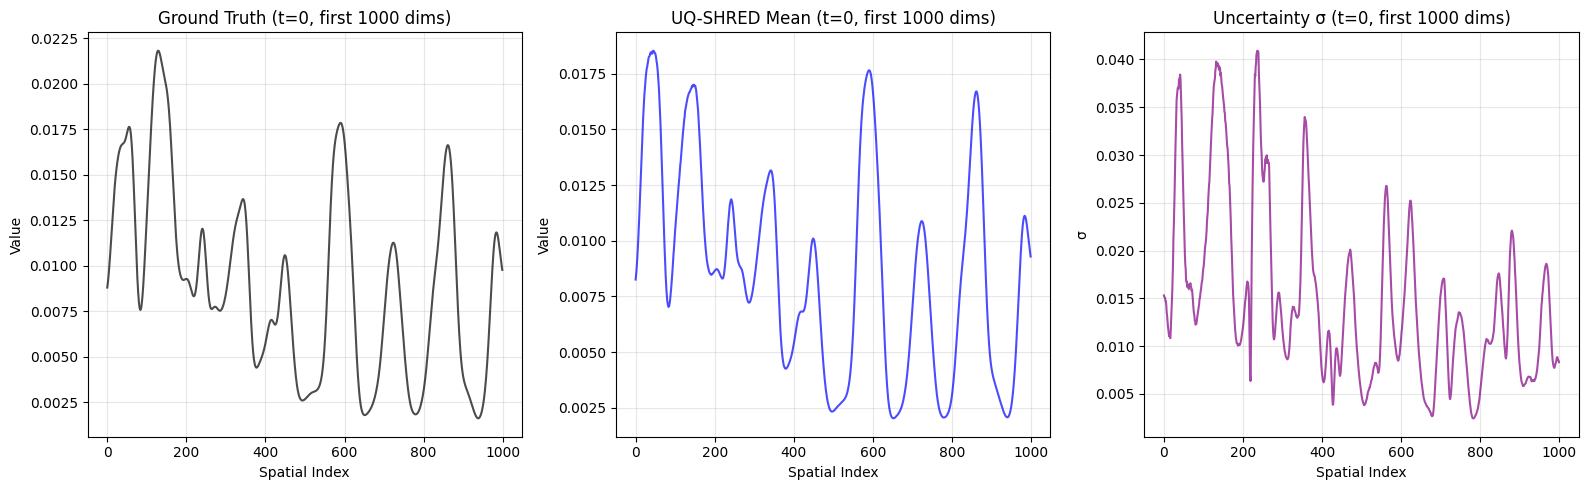

In [12]:
# E4 Additional: Spatial snapshot comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

truth_snapshot = test_truth_np[0][:1000]
mean_snapshot = mean_orig[0][:1000]
std_snapshot = std_recon.cpu().numpy()[0][:1000]

axes[0].plot(truth_snapshot, alpha=0.7, color='black')
axes[0].set_title('Ground Truth (t=0, first 1000 dims)')
axes[0].set_xlabel('Spatial Index')
axes[0].set_ylabel('Value')
axes[0].grid(alpha=0.3)

axes[1].plot(mean_snapshot, alpha=0.7, color='blue')
axes[1].set_title('UQ-SHRED Mean (t=0, first 1000 dims)')
axes[1].set_xlabel('Spatial Index')
axes[1].set_ylabel('Value')
axes[1].grid(alpha=0.3)

axes[2].plot(std_snapshot, alpha=0.7, color='purple')
axes[2].set_title('Uncertainty σ (t=0, first 1000 dims)')
axes[2].set_xlabel('Spatial Index')
axes[2].set_ylabel('σ')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{results_dir}/E4_spatial_snapshot.png', dpi=150)
plt.show()

# E5: Forecasting

In [13]:
sensor_data = transformed_X[:, sensor_locations]
forecast_in = np.zeros((n - lags, lags, num_sensors))
forecast_out = np.zeros((n - lags, num_sensors))
for i in range(n - lags):
    forecast_in[i] = sensor_data[i:i+lags]
    forecast_out[i] = sensor_data[i+lags]

train_fc_in = torch.tensor(forecast_in[train_indices], dtype=torch.float32).to(device)
train_fc_out = torch.tensor(forecast_out[train_indices], dtype=torch.float32).to(device)
valid_fc_in = torch.tensor(forecast_in[valid_indices], dtype=torch.float32).to(device)
valid_fc_out = torch.tensor(forecast_out[valid_indices], dtype=torch.float32).to(device)

train_fc_dataset = TimeSeriesDataset(train_fc_in, train_fc_out)
valid_fc_dataset = TimeSeriesDataset(valid_fc_in, valid_fc_out)

print('Training SHRED forecaster...')
shred_forecaster = SHRED(num_sensors, num_sensors, hidden_size=64, hidden_layers=2, l1=100, l2=150, dropout=0.1).to(device)
fit(shred_forecaster, train_fc_dataset, valid_fc_dataset, batch_size=64, num_epochs=200, lr=1e-3, verbose=True, patience=5)

print('Training UQ forecaster...')
forecaster = UQ_Forecaster(input_size=num_sensors, hidden_size=64, hidden_layers=2, noise_dim=50).to(device)
fit_uq(forecaster, train_fc_dataset, valid_fc_dataset, batch_size=20, num_epochs=1000, lr=1e-3, verbose=True, patience=5)

print('E5 complete')

Training SHRED forecaster...
Training epoch 1
Error tensor(0.9080, device='cuda:0')
Training epoch 20
Error tensor(0.3050, device='cuda:0')
Training epoch 40
Error tensor(0.1987, device='cuda:0')
Training epoch 60
Error tensor(0.1746, device='cuda:0')
Training epoch 80
Error tensor(0.1439, device='cuda:0')
Training epoch 100
Error tensor(0.1202, device='cuda:0')
Training epoch 120
Error tensor(0.1184, device='cuda:0')
Training epoch 140
Error tensor(0.1145, device='cuda:0')
Training epoch 160
Error tensor(0.1060, device='cuda:0')
Training epoch 180
Error tensor(0.1113, device='cuda:0')
Training epoch 200
Error tensor(0.1051, device='cuda:0')
Training UQ forecaster...
Epoch 1: error=0.7455
Epoch 20: error=0.2716
Epoch 40: error=0.1677
Epoch 60: error=0.1351
Epoch 80: error=0.1316
Epoch 100: error=0.1306
Epoch 120: error=0.1151
Epoch 140: error=0.1154
Epoch 160: error=0.1030
Epoch 180: error=0.1033
Epoch 200: error=0.0990
Epoch 220: error=0.0971
Epoch 240: error=0.0974
Epoch 260: error=0

In [14]:
# Generate forecasts
horizon = 50
initial = test_data_in[0:1]

shred_forecaster.eval()
with torch.no_grad():
    history = initial.clone()
    shred_traj = []
    for t in range(horizon):
        next_val = shred_forecaster(history)
        shred_traj.append(next_val.cpu().numpy().squeeze())
        history = torch.cat([history[:, 1:, :], next_val.unsqueeze(1)], dim=1)
shred_traj = np.array(shred_traj)

uq_traj = forecaster.sample_trajectory(initial, horizon=horizon, n_samples=50).squeeze(1).cpu().numpy()
mean_traj = uq_traj.mean(axis=0)
median_traj = np.median(uq_traj, axis=0)

start_idx = test_indices[0] + lags
gt_future = sensor_data[start_idx:start_idx+horizon]

shred_fc_error = np.linalg.norm(shred_traj - gt_future) / np.linalg.norm(gt_future)
uq_fc_error = np.linalg.norm(mean_traj - gt_future) / np.linalg.norm(gt_future)
uq_median_fc_error = np.linalg.norm(median_traj - gt_future) / np.linalg.norm(gt_future)

print(f'E5 Forecast: SHRED={shred_fc_error:.4f}, UQ Mean={uq_fc_error:.4f}, UQ Median={uq_median_fc_error:.4f}')

E5 Forecast: SHRED=0.0887, UQ Mean=0.0646, UQ Median=0.0652


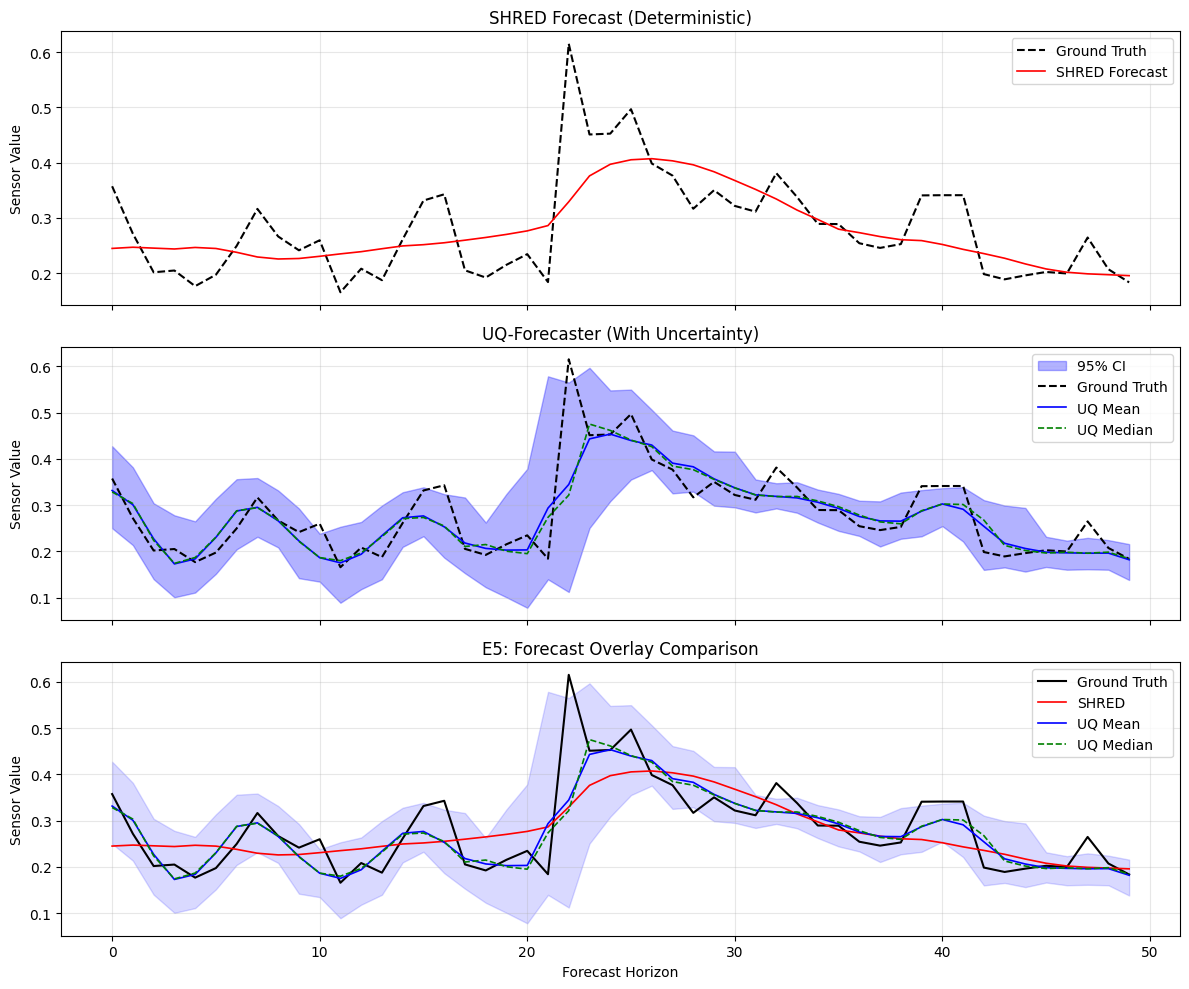

In [15]:
# E5 Visualization: Forecast Comparison
std_traj = uq_traj.std(axis=0)
lower_traj = np.percentile(uq_traj, 2.5, axis=0)
upper_traj = np.percentile(uq_traj, 97.5, axis=0)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
t = np.arange(horizon)
sensor_idx = 0

# SHRED deterministic forecast
axes[0].plot(t, gt_future[:, sensor_idx], 'k--', linewidth=1.5, label='Ground Truth')
axes[0].plot(t, shred_traj[:, sensor_idx], 'r-', linewidth=1.2, label='SHRED Forecast')
axes[0].set_ylabel('Sensor Value')
axes[0].legend()
axes[0].set_title('SHRED Forecast (Deterministic)')
axes[0].grid(alpha=0.3)

# UQ-SHRED forecast
axes[1].fill_between(t, lower_traj[:, sensor_idx], upper_traj[:, sensor_idx],
                alpha=0.3, color='blue', label='95% CI')
axes[1].plot(t, gt_future[:, sensor_idx], 'k--', linewidth=1.5, label='Ground Truth')
axes[1].plot(t, mean_traj[:, sensor_idx], 'b-', linewidth=1.2, label='UQ Mean')
axes[1].plot(t, median_traj[:, sensor_idx], 'g--', linewidth=1.2, label='UQ Median')
axes[1].set_ylabel('Sensor Value')
axes[1].legend()
axes[1].set_title('UQ-Forecaster (With Uncertainty)')
axes[1].grid(alpha=0.3)

# Overlay
axes[2].plot(t, gt_future[:, sensor_idx], 'k-', linewidth=1.5, label='Ground Truth')
axes[2].plot(t, shred_traj[:, sensor_idx], 'r-', linewidth=1.2, label='SHRED')
axes[2].plot(t, mean_traj[:, sensor_idx], 'b-', linewidth=1.2, label='UQ Mean')
axes[2].plot(t, median_traj[:, sensor_idx], 'g--', linewidth=1.2, label='UQ Median')
axes[2].fill_between(t, lower_traj[:, sensor_idx], upper_traj[:, sensor_idx], alpha=0.15, color='blue')
axes[2].set_xlabel('Forecast Horizon')
axes[2].set_ylabel('Sensor Value')
axes[2].legend()
axes[2].set_title('E5: Forecast Overlay Comparison')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{results_dir}/E5_forecast_comparison.png', dpi=150)
plt.show()

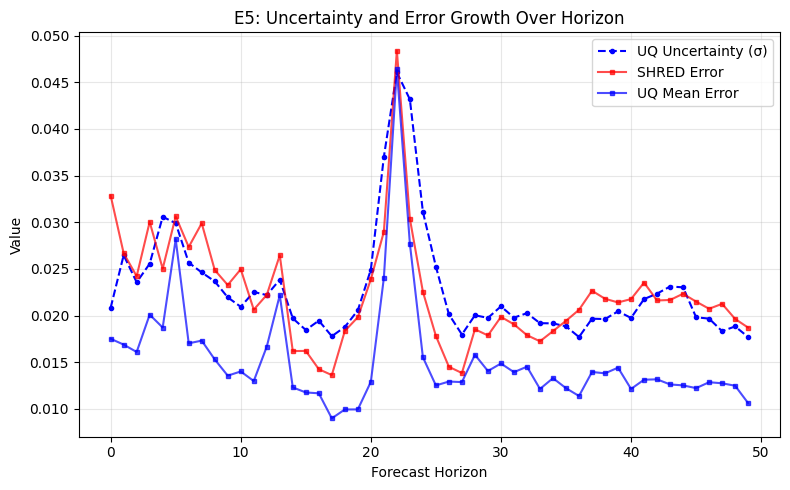

In [16]:
# E5: Uncertainty growth over horizon
avg_std_horizon = std_traj.mean(axis=1)
shred_error_horizon = np.abs(shred_traj - gt_future).mean(axis=1)
uq_error_horizon = np.abs(mean_traj - gt_future).mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(horizon), avg_std_horizon, 'b--', marker='o', markersize=3, label='UQ Uncertainty (σ)')
ax.plot(np.arange(horizon), shred_error_horizon, 'r-', marker='s', markersize=3, alpha=0.7, label='SHRED Error')
ax.plot(np.arange(horizon), uq_error_horizon, 'b-', marker='s', markersize=3, alpha=0.7, label='UQ Mean Error')
ax.set_xlabel('Forecast Horizon')
ax.set_ylabel('Value')
ax.set_title('E5: Uncertainty and Error Growth Over Horizon')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{results_dir}/E5_uncertainty_growth.png', dpi=150)
plt.show()

# E6: Ablation

E6: Ablation
  n=10: Error=0.0474, CRPS=0.0093, Cov=53.0%
  n=25: Error=0.0473, CRPS=0.0094, Cov=62.6%
  n=40: Error=0.0463, CRPS=0.0095, Cov=63.9%
  n=50: Error=0.0465, CRPS=0.0094, Cov=64.9%


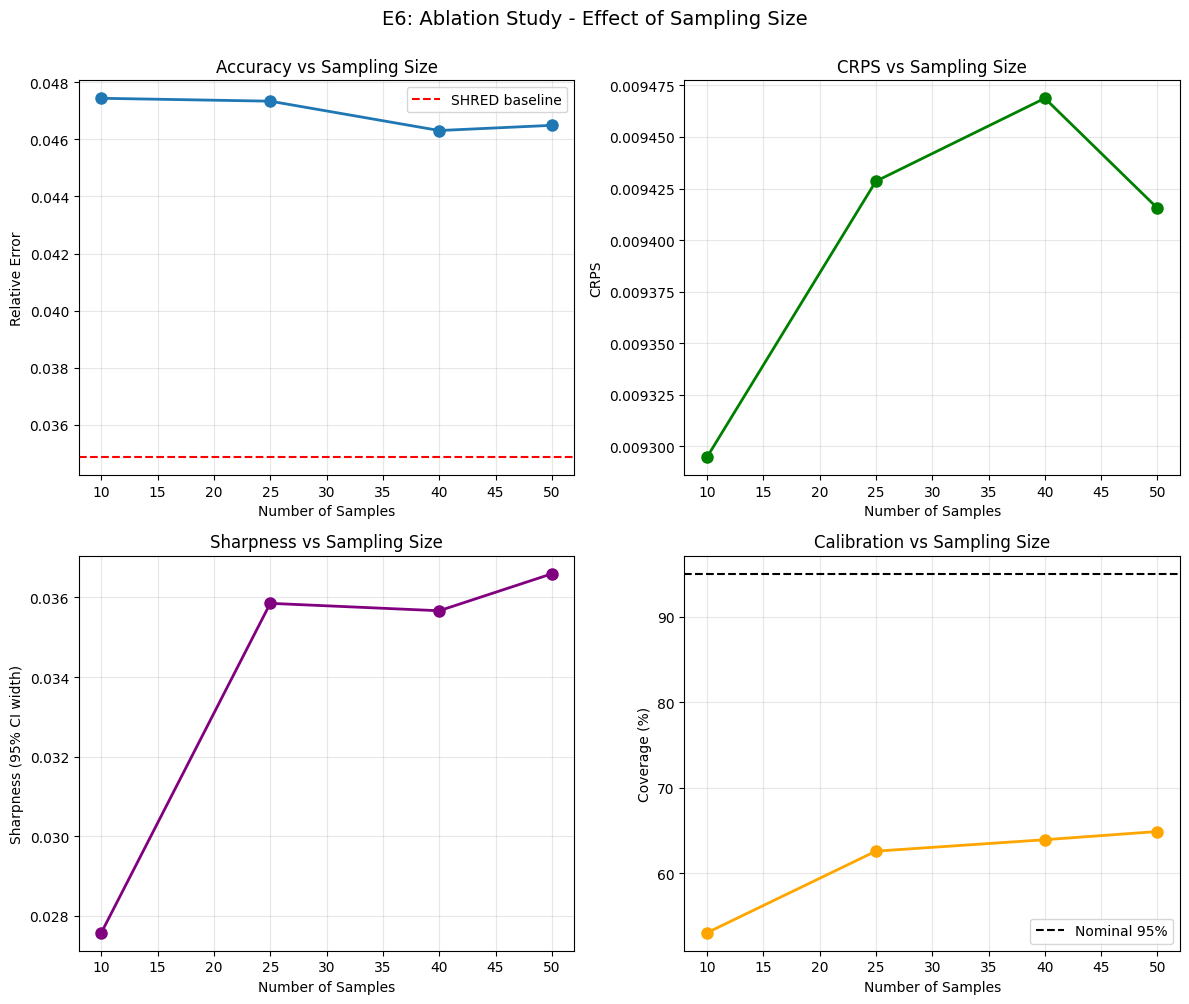

In [17]:
n_samples_list = [10, 25, 40, 50]
ablation_results = []

print('E6: Ablation')
for n_samp in n_samples_list:
    samp = uq_shred.sample(test_dataset.X, n_samples=n_samp)
    mean_pred = samp.mean(dim=0)
    rel_error = (torch.linalg.norm(mean_pred - test_dataset.Y) / torch.linalg.norm(test_dataset.Y)).item()
    crps = uq.crps(samp, test_dataset.Y)
    sharp_val = uq.sharpness(samp, conf=0.95)
    cal = uq.calibration_scores(samp, test_dataset.Y, levels=[0.95])[0.95]
    
    ablation_results.append({
        'n_samples': n_samp,
        'rel_error': rel_error,
        'crps': crps,
        'sharpness': sharp_val,
        'coverage_95': cal
    })
    print(f'  n={n_samp}: Error={rel_error:.4f}, CRPS={crps:.4f}, Cov={cal*100:.1f}%')

# Plot ablation (2x2 grid)
n_samp_arr = np.array([r['n_samples'] for r in ablation_results])
rel_err_arr = np.array([r['rel_error'] for r in ablation_results])
crps_arr = np.array([r['crps'] for r in ablation_results])
sharp_arr = np.array([r['sharpness'] for r in ablation_results])
cov_arr = np.array([r['coverage_95'] for r in ablation_results]) * 100

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Relative error
axes[0, 0].plot(n_samp_arr, rel_err_arr, 'o-', linewidth=2, markersize=8)
axes[0, 0].axhline(shred_error, color='r', linestyle='--', label='SHRED baseline')
axes[0, 0].set_xlabel('Number of Samples')
axes[0, 0].set_ylabel('Relative Error')
axes[0, 0].set_title('Accuracy vs Sampling Size')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# CRPS
axes[0, 1].plot(n_samp_arr, crps_arr, 'o-', linewidth=2, markersize=8, color='green')
axes[0, 1].set_xlabel('Number of Samples')
axes[0, 1].set_ylabel('CRPS')
axes[0, 1].set_title('CRPS vs Sampling Size')
axes[0, 1].grid(alpha=0.3)

# Sharpness
axes[1, 0].plot(n_samp_arr, sharp_arr, 'o-', linewidth=2, markersize=8, color='purple')
axes[1, 0].set_xlabel('Number of Samples')
axes[1, 0].set_ylabel('Sharpness (95% CI width)')
axes[1, 0].set_title('Sharpness vs Sampling Size')
axes[1, 0].grid(alpha=0.3)

# Coverage
axes[1, 1].plot(n_samp_arr, cov_arr, 'o-', linewidth=2, markersize=8, color='orange')
axes[1, 1].axhline(95, color='k', linestyle='--', label='Nominal 95%')
axes[1, 1].set_xlabel('Number of Samples')
axes[1, 1].set_ylabel('Coverage (%)')
axes[1, 1].set_title('Calibration vs Sampling Size')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle('E6: Ablation Study - Effect of Sampling Size', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(f'{results_dir}/E6_ablation.png', dpi=150)
plt.show()

# Summary

In [18]:
summary = f"""={'='*80}
UQ-SHRED RESULTS: {dataset_name}
={'='*80}
Timestamp: {timestamp}

E1 RECONSTRUCTION:
  SHRED Error:      {shred_error:.4f}
  UQ Mean Error:    {uq_mean_error:.4f}
  UQ Median Error:  {uq_median_error:.4f}
  CRPS:             {crps_score:.4f}
  Sharpness:        {sharp:.4f}
  Coverage (95%):   {cal_scores[0.95]*100:.1f}%
  Correlation:      {corr:.3f}

E5 FORECASTING:
  SHRED:            {shred_fc_error:.4f}
  UQ Mean:          {uq_fc_error:.4f}
  UQ Median:        {uq_median_fc_error:.4f}
={'='*80}
"""
print(summary)

with open(f'{results_dir}/metrics.txt', 'w') as f:
    f.write(summary)
with open(f'{results_dir}/config.json', 'w') as f:
    json.dump(config, f, indent=2)
with open(f'{results_dir}/ablation_results.json', 'w') as f:
    json.dump(ablation_results, f, indent=2)

print(f'\n✓ All results saved to: {results_dir}/')

UQ-SHRED RESULTS: FLOW
Timestamp: 20260214_172454

E1 RECONSTRUCTION:
  SHRED Error:      0.0349
  UQ Mean Error:    0.0468
  UQ Median Error:  0.0465
  CRPS:             0.0095
  Sharpness:        0.0361
  Coverage (95%):   64.3%
  Correlation:      0.394

E5 FORECASTING:
  SHRED:            0.0887
  UQ Mean:          0.0646
  UQ Median:        0.0652


✓ All results saved to: results/FLOW_20260214_172454/
